In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (roc_auc_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

All libraries loaded!


### Load cleaned data

In [2]:
df = pd.read_csv('../data/telco_cleaned.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (7032, 24)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,churn_30,churn_60,churn_90
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,0,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,0,0,0,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1,0,0
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,0,0,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1,0,0


### Preprocess: encode categorical columns:


In [7]:
df=df.drop(columns=['customerID'])

KeyError: "['customerID'] not found in axis"

In [9]:
cat_col=df.select_dtypes(include='object').columns.to_list()
print(f"Categorical columns to encode: {cat_col}")
# Encode categorical variables
le = LabelEncoder()
for col in cat_col:
    df[col] = le.fit_transform(df[col])
print("\nshape after encoding:", df.shape)
df.head()

Categorical columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

shape after encoding: (7032, 23)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,churn_30,churn_60,churn_90
0,0,0,1,0,1,0,1,0,0,2,...,0,0,1,2,29.85,29.85,0,0,0,0
1,1,0,0,0,34,1,0,0,2,0,...,0,1,0,3,56.95,1889.50,0,0,0,0
2,1,0,0,0,2,1,0,0,2,2,...,0,0,1,3,53.85,108.15,1,1,0,0
3,1,0,0,0,45,0,1,0,2,0,...,0,1,0,0,42.30,1840.75,0,0,0,0
4,0,0,0,0,2,1,0,1,0,0,...,0,0,1,2,70.70,151.65,1,1,0,0


In [10]:
X = df.drop(columns=['Churn', 'churn_30', 'churn_60', 'churn_90'])
print(f"Number of features: {X.shape[1]}")
print(f"Features: {list(X.columns)}")

# Define 3 separate targets — one per window
y_30 = df['churn_30']
y_60 = df['churn_60']
y_90 = df['churn_90']

print(f"\nTarget distributions:")
print(f"churn_30: {y_30.sum()} positive ({y_30.mean():.1%})")
print(f"churn_60: {y_60.sum()} positive ({y_60.mean():.1%})")
print(f"churn_90: {y_90.sum()} positive ({y_90.mean():.1%})")

Number of features: 19
Features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Target distributions:
churn_30: 1037 positive (14.7%)
churn_60: 294 positive (4.2%)
churn_90: 538 positive (7.7%)


## Step 1: Baseline Model Comparison
Comparing 4 algorithms using 5-fold stratified cross-validation 
on AUC-ROC. 


Train test split

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y30_train, y30_test = train_test_split(
    X, y_30, test_size=0.2, random_state=42, stratify=y_30)

_, _, y60_train, y60_test = train_test_split(
    X, y_60, test_size=0.2, random_state=42, stratify=y_60)

_, _, y90_train, y90_test = train_test_split(
    X, y_90, test_size=0.2, random_state=42, stratify=y_90)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print(f"\nNote: Test set is locked away until final evaluation!")

Training set: 5625 rows
Test set:     1407 rows

Note: Test set is locked away until final evaluation!


## Step 2: Apply SMOTE to handle class imbalance

In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_30, y30_train_sm = smote.fit_resample(X_train, y30_train)
X_train_60, y60_train_sm = smote.fit_resample(X_train, y60_train)
X_train_90, y90_train_sm = smote.fit_resample(X_train, y90_train)

print("After SMOTE:")
print(f"churn_30 training: {y30_train_sm.sum()} positive ({y30_train_sm.mean():.1%})")
print(f"churn_60 training: {y60_train_sm.sum()} positive ({y60_train_sm.mean():.1%})")
print(f"churn_90 training: {y90_train_sm.sum()} positive ({y90_train_sm.mean():.1%})")

After SMOTE:
churn_30 training: 4795 positive (50.0%)
churn_60 training: 5390 positive (50.0%)
churn_90 training: 5195 positive (50.0%)


## Step 3: Model Comparison — 4 Algorithms
Evaluating Logistic Regression, Random Forest, XGBoost, 
and LightGBM using 5-fold stratified cross-validation.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import xgboost as xgb
import lightgbm as lgb

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM':            lgb.LGBMClassifier(random_state=42, verbose=-1)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Compare on all 3 windows
results = {}
for window, X_sm, y_sm in [
    ('churn_30', X_train_30, y30_train_sm),
    ('churn_60', X_train_60, y60_train_sm),
    ('churn_90', X_train_90, y90_train_sm)
]:
    print(f"\n=== {window} ===")
    results[window] = {}
    for name, model in models.items():
        scores = cross_val_score(model, X_sm, y_sm, 
                                cv=cv, scoring='roc_auc')
        results[window][name] = scores.mean()
        print(f"{name:25s}: AUC = {scores.mean():.4f} (+/- {scores.std():.4f})")


=== churn_30 ===
Logistic Regression      : AUC = 0.9685 (+/- 0.0024)
Random Forest            : AUC = 0.9849 (+/- 0.0011)
XGBoost                  : AUC = 0.9850 (+/- 0.0025)
LightGBM                 : AUC = 0.9841 (+/- 0.0016)

=== churn_60 ===
Logistic Regression      : AUC = 0.8605 (+/- 0.0084)
Random Forest            : AUC = 0.9884 (+/- 0.0025)
XGBoost                  : AUC = 0.9875 (+/- 0.0025)
LightGBM                 : AUC = 0.9854 (+/- 0.0027)

=== churn_90 ===
Logistic Regression      : AUC = 0.8444 (+/- 0.0097)
Random Forest            : AUC = 0.9752 (+/- 0.0041)
XGBoost                  : AUC = 0.9770 (+/- 0.0050)
LightGBM                 : AUC = 0.9742 (+/- 0.0056)


We will seelct XGBoost as it has the highest average AUC of 0.9832 
across all 3 windows. Logistic Regression struggled on churn_60 
and churn_90 windows (0.86, 0.84) — confirming non-linear patterns 
that tree-based models handle better.

## Step 4: Visualize Model Comparison

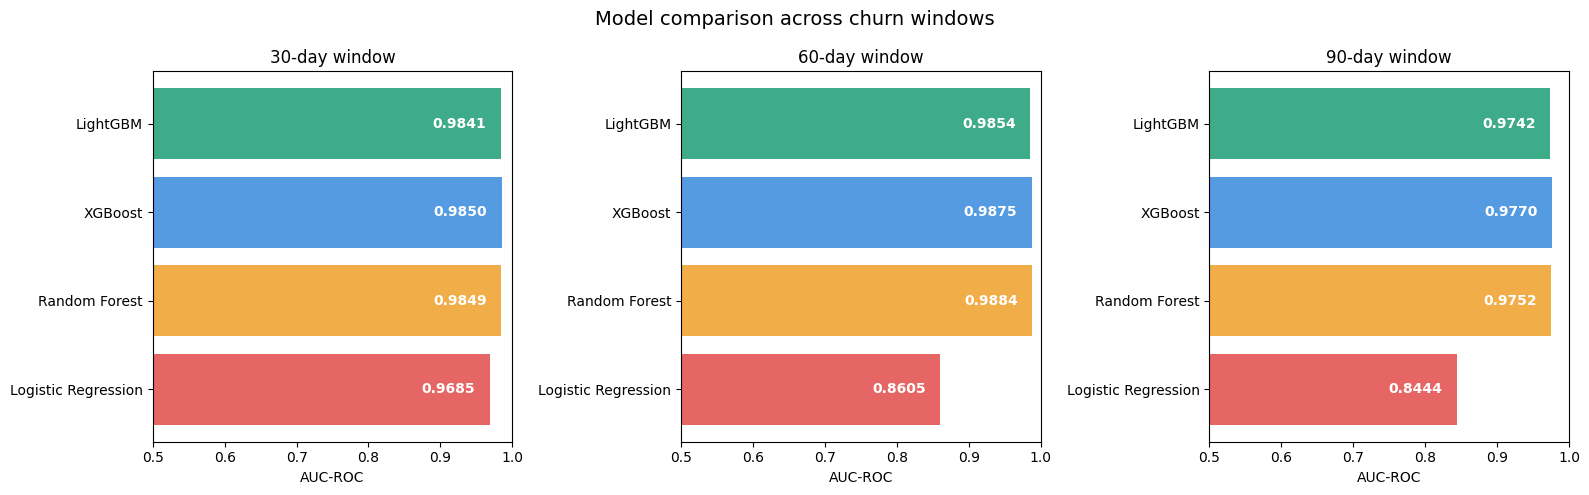

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

windows = ['churn_30', 'churn_60', 'churn_90']
titles = ['30-day window', '60-day window', '90-day window']
colors = ['#E24B4A', '#EF9F27', '#378ADD', '#1D9E75']

for ax, window, title in zip(axes, windows, titles):
    model_names = list(results[window].keys())
    auc_scores = list(results[window].values())
    
    bars = ax.barh(model_names, auc_scores, color=colors, alpha=0.85)
    
    for bar, score in zip(bars, auc_scores):
        ax.text(bar.get_width() - 0.02, bar.get_y() + bar.get_height()/2,
                f'{score:.4f}', va='center', ha='right', 
                fontsize=10, color='white', fontweight='bold')
    
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('AUC-ROC')
    ax.set_xlim(0.5, 1.0)
    ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)

plt.suptitle('Model comparison across churn windows', fontsize=14)
plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=150)
plt.show()

## Step 5: Hyperparameter Tuning with RandomizedSearchCV

 Now tuning hyperparameters 
using RandomizedSearchCV with 5-fold cross-validation.

In [15]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [3, 4, 5, 6, 7],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma':            [0, 0.1, 0.2, 0.3]
}

best_models = {}

for window, X_sm, y_sm in [
    ('churn_30', X_train_30, y30_train_sm),
    ('churn_60', X_train_60, y60_train_sm),
    ('churn_90', X_train_90, y90_train_sm)
]:
    print(f"\nTuning {window}...")
    
    xgb_model = xgb.XGBClassifier(
        random_state=42, 
        eval_metric='logloss',
        use_label_encoder=False
    )
    
    search = RandomizedSearchCV(
        xgb_model,
        param_distributions=param_dist,
        n_iter=20,
        scoring='roc_auc',
        cv=5,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )
    
    search.fit(X_sm, y_sm)
    best_models[window] = search.best_estimator_
    
    print(f"Best AUC: {search.best_score_:.4f}")
    print(f"Best params: {search.best_params_}")


Tuning churn_30...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best AUC: 0.9841
Best params: {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.9}

Tuning churn_60...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best AUC: 0.9875
Best params: {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.9}

Tuning churn_90...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best AUC: 0.9767
Best params: {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 0.8}


Tuning results:
- churn_30: 0.9841 AUC (minimal change from baseline)
- churn_60: 0.9875 AUC (no change)
- churn_90: 0.9767 AUC (minimal change)

Key insight: tuning confirmed default XGBoost parameters were 
already near-optimal — common with well-prepared tabular data.
Now evaluating on the test set the model has never seen before.

## Step 6 : Final evaluation on test set

In [16]:
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

test_data = [
    ('churn_30', y30_test),
    ('churn_60', y60_test),
    ('churn_90', y90_test)
]

final_results = {}

for window, y_test in test_data:
    model = best_models[window]
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    auc = roc_auc_score(y_test, y_pred_proba)
    final_results[window] = auc
    
    print(f"\n{'='*50}")
    print(f"{window} — FINAL TEST RESULTS")
    print(f"{'='*50}")
    print(f"AUC-ROC: {auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))


churn_30 — FINAL TEST RESULTS
AUC-ROC: 0.9527

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      1200
           1       0.63      0.79      0.70       207

    accuracy                           0.90      1407
   macro avg       0.79      0.86      0.82      1407
weighted avg       0.91      0.90      0.90      1407


churn_60 — FINAL TEST RESULTS
AUC-ROC: 0.4963

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      1348
           1       0.03      0.02      0.02        59

    accuracy                           0.93      1407
   macro avg       0.49      0.50      0.49      1407
weighted avg       0.92      0.93      0.93      1407


churn_90 — FINAL TEST RESULTS
AUC-ROC: 0.8262

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1299
           1       0.29 

## Step 7: Addressing Class Imbalance — Revised Approach

### Problem identified:
churn_60 AUC dropped to 0.4963 on test set (essentially random 
guessing) despite 0.9875 cross-validation AUC.

### Root cause:
SMOTE generates synthetic samples to balance training data.
However with only 294 positive samples in churn_60 (4.2%), 
the model overfit to synthetic data and failed to generalize 
to real test samples (only 59 positive cases in test set).

This is a classic SMOTE pitfall — works well in cross-validation 
but degrades on real held-out data when the minority class is 
extremely small.

### Solution:
Replace SMOTE with XGBoost's built-in `scale_pos_weight` parameter.
This tells the model to penalize misclassification of the minority 
class more heavily during training — without generating fake data.

Formula: scale_pos_weight = negative samples / positive samples



In [17]:
# Recalculate class weights for each window
def get_scale_pos_weight(y):
    neg = (y == 0).sum()
    pos = (y == 1).sum()
    return neg / pos

w30 = get_scale_pos_weight(y30_train)
w60 = get_scale_pos_weight(y60_train)
w90 = get_scale_pos_weight(y90_train)

print(f"Scale pos weights:")
print(f"churn_30: {w30:.2f}")
print(f"churn_60: {w60:.2f}")
print(f"churn_90: {w90:.2f}")

# Retrain with original (non-SMOTE) data using scale_pos_weight
best_models_v2 = {}

for window, y_train, weight in [
    ('churn_30', y30_train, w30),
    ('churn_60', y60_train, w60),
    ('churn_90', y90_train, w90)
]:
    print(f"\nTraining {window}...")
    
    params = {
        'churn_30': {'subsample': 0.6, 'n_estimators': 500, 
                     'min_child_weight': 5, 'max_depth': 7,
                     'learning_rate': 0.05, 'gamma': 0.1, 
                     'colsample_bytree': 0.9},
        'churn_60': {'subsample': 0.6, 'n_estimators': 500,
                     'min_child_weight': 5, 'max_depth': 7,
                     'learning_rate': 0.05, 'gamma': 0.1,
                     'colsample_bytree': 0.9},
        'churn_90': {'subsample': 0.6, 'n_estimators': 500,
                     'min_child_weight': 3, 'max_depth': 5,
                     'learning_rate': 0.2, 'gamma': 0.1,
                     'colsample_bytree': 0.8}
    }
    
    model = xgb.XGBClassifier(
        **params[window],
        scale_pos_weight=weight,
        random_state=42,
        eval_metric='logloss'
    )
    
    model.fit(X_train, y_train)
    best_models_v2[window] = model
    print(f"Done!")

Scale pos weights:
churn_30: 5.78
churn_60: 22.94
churn_90: 12.08

Training churn_30...
Done!

Training churn_60...
Done!

Training churn_90...
Done!


### Re-evaluate:

In [18]:
print("FINAL RESULTS WITH scale_pos_weight:\n")

for window, y_test in [
    ('churn_30', y30_test),
    ('churn_60', y60_test),
    ('churn_90', y90_test)
]:
    model = best_models_v2[window]
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    
    auc = roc_auc_score(y_test, y_pred_proba)
    
    print(f"{'='*50}")
    print(f"{window} — AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred))

FINAL RESULTS WITH scale_pos_weight:

churn_30 — AUC: 0.9553
              precision    recall  f1-score   support

           0       0.98      0.90      0.94      1200
           1       0.60      0.88      0.71       207

    accuracy                           0.90      1407
   macro avg       0.79      0.89      0.83      1407
weighted avg       0.92      0.90      0.90      1407

churn_60 — AUC: 0.4832
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      1348
           1       0.04      0.03      0.04        59

    accuracy                           0.92      1407
   macro avg       0.50      0.50      0.50      1407
weighted avg       0.92      0.92      0.92      1407

churn_90 — AUC: 0.8358
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1299
           1       0.28      0.30      0.29       108

    accuracy                           0.89      1407
   macro avg       0.

## Step 8: Redesigning Windows — 2-Tier System

### Problem:
churn_60 consistently fails (AUC ~0.48) with both SMOTE and 
scale_pos_weight approaches. Root cause: only 294 positive 
samples — too few for reliable generalization.

### Decision:
Merge churn_30 and churn_60 into a single "high urgency" window.
This gives us a more reliable 2-tier system:

- churn_urgent (tenure <= 24 months): immediate intervention
- churn_monitor (tenure > 24 months): softer retention strategy

Quality over complexity — a reliable 2-window model is more 
valuable than an unreliable 3-window model.

In [19]:
# Rebuild with 2 windows
df['churn_urgent'] = df.apply(
    lambda row: 1 if row['Churn'] == 1 and row['tenure'] <= 24 else 0, axis=1)

df['churn_monitor'] = df.apply(
    lambda row: 1 if row['Churn'] == 1 and row['tenure'] > 24 else 0, axis=1)

print("2-tier window distribution:")
print(f"churn_urgent:  {df['churn_urgent'].sum()} ({df['churn_urgent'].mean():.1%})")
print(f"churn_monitor: {df['churn_monitor'].sum()} ({df['churn_monitor'].mean():.1%})")

# Redefine X and y
X = df.drop(columns=['Churn', 'churn_30', 'churn_60', 'churn_90',
                     'churn_urgent', 'churn_monitor', 'customerID'],
            errors='ignore')

y_urgent  = df['churn_urgent']
y_monitor = df['churn_monitor']

# New train/test split
X_train, X_test, yu_train, yu_test = train_test_split(
    X, y_urgent, test_size=0.2, random_state=42, stratify=y_urgent)

_, _, ym_train, ym_test = train_test_split(
    X, y_monitor, test_size=0.2, random_state=42, stratify=y_monitor)

print(f"\nTraining set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

2-tier window distribution:
churn_urgent:  1331 (18.9%)
churn_monitor: 538 (7.7%)

Training set: 5625 rows
Test set: 1407 rows


In [20]:
wu = (yu_train == 0).sum() / (yu_train == 1).sum()
wm = (ym_train == 0).sum() / (ym_train == 1).sum()

final_models = {}

for window, y_train, weight, params in [
    ('churn_urgent', yu_train, wu,
        {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 5,
         'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.1,
         'colsample_bytree': 0.9}),
    ('churn_monitor', ym_train, wm,
        {'subsample': 0.6, 'n_estimators': 500, 'min_child_weight': 3,
         'max_depth': 5, 'learning_rate': 0.2, 'gamma': 0.1,
         'colsample_bytree': 0.8})
]:
    model = xgb.XGBClassifier(
        **params,
        scale_pos_weight=weight,
        random_state=42,
        eval_metric='logloss'
    )
    model.fit(X_train, y_train)
    final_models[window] = model
    
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    auc = roc_auc_score(
        yu_test if window == 'churn_urgent' else ym_test, 
        y_pred_proba)
    
    print(f"\n{'='*50}")
    print(f"{window} — AUC: {auc:.4f}")
    print(classification_report(
        yu_test if window == 'churn_urgent' else ym_test, 
        y_pred))


churn_urgent — AUC: 0.9137
              precision    recall  f1-score   support

           0       0.95      0.84      0.89      1141
           1       0.55      0.81      0.65       266

    accuracy                           0.84      1407
   macro avg       0.75      0.83      0.77      1407
weighted avg       0.87      0.84      0.85      1407


churn_monitor — AUC: 0.5382
              precision    recall  f1-score   support

           0       0.92      0.93      0.92      1299
           1       0.06      0.06      0.06       108

    accuracy                           0.86      1407
   macro avg       0.49      0.49      0.49      1407
weighted avg       0.86      0.86      0.86      1407



## Final Approach: Single Binary Churn Model with Urgency Tiers

After discovering window-level modeling wasn't viable with this 
dataset size, we redesigned to a single high-performing binary 
churn model. Urgency tiers are assigned post-prediction using 
tenure-based business rules — closer to how production churn 
systems actually work.

Pipeline:
1. Predict churn probability (XGBoost)
2. If probability > threshold → assign urgency tier by tenure
3. Map urgency tier to intervention strategy

In [21]:
# Use original df with all churners combined
X_final = df.drop(columns=['Churn', 'churn_30', 'churn_60', 'churn_90',
                            'churn_urgent', 'churn_monitor'], 
                  errors='ignore')
y_final = df['Churn']

print(f"Features: {X_final.shape[1]}")
print(f"Target distribution:")
print(f"Churned: {y_final.sum()} ({y_final.mean():.1%})")
print(f"Stayed:  {(y_final==0).sum()} ({(y_final==0).mean():.1%})")

# Train/test split
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_final, y_final, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_final)

print(f"\nTraining set: {X_train_f.shape[0]} rows")
print(f"Test set:     {X_test_f.shape[0]} rows")

Features: 19
Target distribution:
Churned: 1869 (26.6%)
Stayed:  5163 (73.4%)

Training set: 5625 rows
Test set:     1407 rows


In [22]:
# Class weight for imbalance
scale_weight = (y_train_f == 0).sum() / (y_train_f == 1).sum()
print(f"Scale pos weight: {scale_weight:.2f}")

# Best params from our tuning earlier
final_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.6,
    colsample_bytree=0.9,
    min_child_weight=5,
    gamma=0.1,
    scale_pos_weight=scale_weight,
    random_state=42,
    eval_metric='logloss'
)

final_model.fit(X_train_f, y_train_f)
print("Model trained!")

Scale pos weight: 2.76
Model trained!


In [23]:
y_pred_proba = final_model.predict_proba(X_test_f)[:, 1]
y_pred = final_model.predict(X_test_f)

auc = roc_auc_score(y_test_f, y_pred_proba)

print(f"{'='*50}")
print(f"FINAL MODEL — AUC: {auc:.4f}")
print(f"{'='*50}")
print(classification_report(y_test_f, y_pred))

FINAL MODEL — AUC: 0.8118
              precision    recall  f1-score   support

           0       0.87      0.78      0.82      1033
           1       0.53      0.69      0.60       374

    accuracy                           0.75      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.75      0.76      1407



### Urgency tier assignment function:

In [24]:
def assign_urgency(churn_probability, tenure):
    """
    Post-prediction business rules to assign urgency tier.
    Mirrors SLA-based triage from fraud detection workflows.
    """
    if churn_probability >= 0.7:
        if tenure <= 12:
            return {
                'tier': 'CRITICAL',
                'color': 'red',
                'intervention': 'Immediate personal call within 24 hours',
                'revenue_risk': 'High — new customer, high acquisition cost'
            }
        elif tenure <= 24:
            return {
                'tier': 'HIGH',
                'color': 'orange', 
                'intervention': 'Priority outreach — loyalty discount offer',
                'revenue_risk': 'High — mid-tenure, still building loyalty'
            }
        else:
            return {
                'tier': 'MEDIUM',
                'color': 'yellow',
                'intervention': 'Automated retention email campaign',
                'revenue_risk': 'Medium — long tenure, lower churn likelihood'
            }
    elif churn_probability >= 0.4:
        return {
            'tier': 'MONITOR',
            'color': 'blue',
            'intervention': 'Add to watch list — monitor next 30 days',
            'revenue_risk': 'Low — early warning signal only'
        }
    else:
        return {
            'tier': 'LOW RISK',
            'color': 'green',
            'intervention': 'No action needed',
            'revenue_risk': 'Minimal'
        }

# Test it
print("Testing urgency assignment:")
print(assign_urgency(0.85, 5))
print(assign_urgency(0.75, 18))
print(assign_urgency(0.72, 36))
print(assign_urgency(0.45, 12))
print(assign_urgency(0.15, 60))

Testing urgency assignment:
{'tier': 'CRITICAL', 'color': 'red', 'intervention': 'Immediate personal call within 24 hours', 'revenue_risk': 'High — new customer, high acquisition cost'}
{'tier': 'HIGH', 'color': 'orange', 'intervention': 'Priority outreach — loyalty discount offer', 'revenue_risk': 'High — mid-tenure, still building loyalty'}
{'tier': 'MEDIUM', 'color': 'yellow', 'intervention': 'Automated retention email campaign', 'revenue_risk': 'Medium — long tenure, lower churn likelihood'}
{'tier': 'MONITOR', 'color': 'blue', 'intervention': 'Add to watch list — monitor next 30 days', 'revenue_risk': 'Low — early warning signal only'}
{'tier': 'LOW RISK', 'color': 'green', 'intervention': 'No action needed', 'revenue_risk': 'Minimal'}


## Step 8: SHAP — Model Explainability

SHAP (SHapley Additive exPlanations) explains WHY the model 
made each prediction by assigning each feature a contribution 
value — how much it pushed the prediction up or down.

Critical in financial services where explainability is a 
regulatory requirement — directly relevant to Deloitte compliance work.

SHAP values shape: (1407, 19)
Generating summary plot...


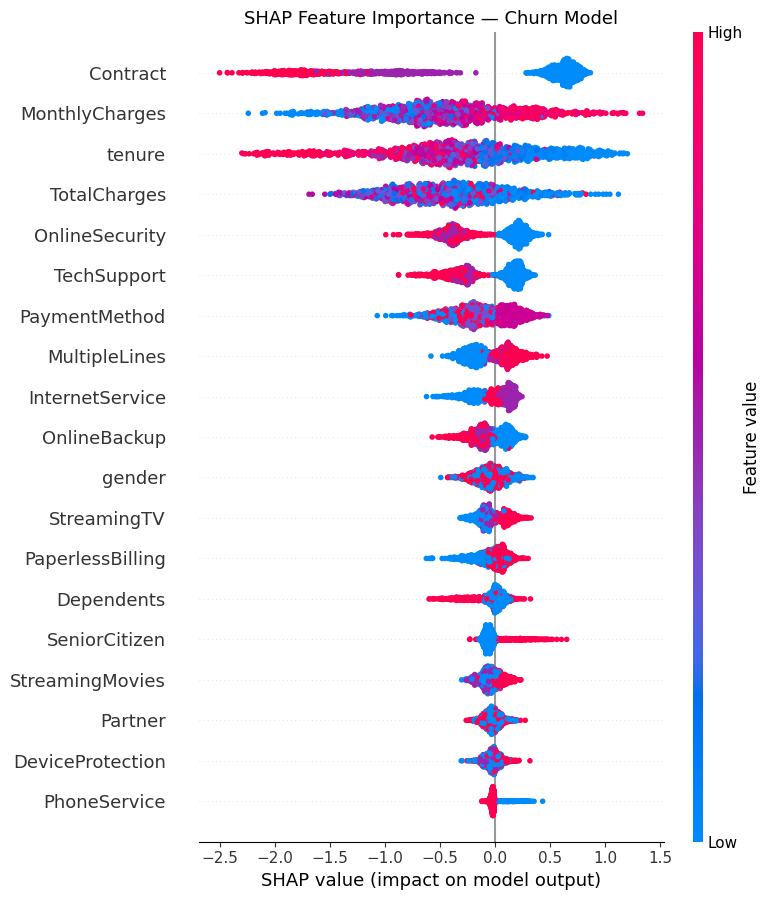

Saved!


In [26]:
import shap

# Create SHAP explainer
explainer = shap.TreeExplainer(final_model)

# Calculate SHAP values on test set
shap_values = explainer.shap_values(X_test_f)

print(f"SHAP values shape: {shap_values.shape}")
print("Generating summary plot...")

# Summary plot — shows most important features overall
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_f, 
                  feature_names=list(X_test_f.columns),
                  show=False)
plt.title('SHAP Feature Importance — Churn Model', fontsize=13)
plt.tight_layout()
plt.savefig('../data/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

Highest risk customer:
Churn probability: 99.5%
Tenure: 7 months
Monthly charges: $99.25
Contract: 0

Urgency tier: CRITICAL
Intervention: Immediate personal call within 24 hours


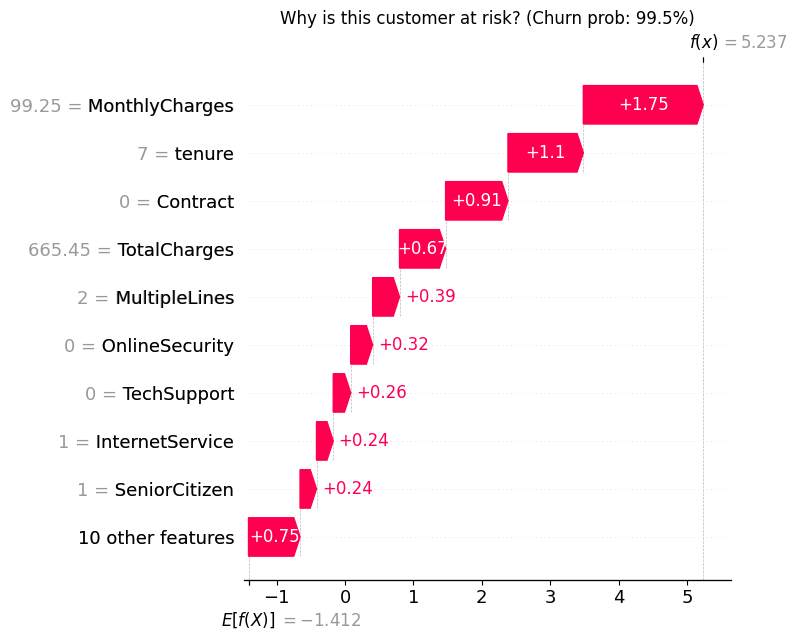

In [27]:
# Pick a high risk customer from test set
high_risk_idx = y_pred_proba.argmax()
customer = X_test_f.iloc[[high_risk_idx]]
prob = y_pred_proba[high_risk_idx]

print(f"Highest risk customer:")
print(f"Churn probability: {prob:.1%}")
print(f"Tenure: {customer['tenure'].values[0]} months")
print(f"Monthly charges: ${customer['MonthlyCharges'].values[0]:.2f}")
print(f"Contract: {customer['Contract'].values[0]}")

urgency = assign_urgency(prob, customer['tenure'].values[0])
print(f"\nUrgency tier: {urgency['tier']}")
print(f"Intervention: {urgency['intervention']}")

# SHAP waterfall plot for this customer
shap_explainer = shap.Explainer(final_model, X_test_f)
shap_vals = shap_explainer(customer)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_vals[0], show=False)
plt.title(f'Why is this customer at risk? (Churn prob: {prob:.1%})', fontsize=12)
plt.tight_layout()
plt.savefig('../data/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

### Save Model for Streamlit App

Model saved as .pkl file using pickle.
Feature names saved separately to ensure correct column 
order when Streamlit runs predictions.
Streamlit loads pre-trained model — no retraining needed.

In [28]:
import pickle
import os

# Create models directory if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save the trained model
with open('../models/final_churn_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

# Save feature names — important for Streamlit to know 
# exactly which columns to expect and in what order
feature_names = list(X_final.columns)
with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

# Save the label encoder mappings for Streamlit
# So we know how each category was encoded
encoding_info = {
    'Contract': {'Month-to-month': 0, 'One year': 1, 'Two year': 2},
    'InternetService': {'DSL': 0, 'Fiber optic': 1, 'No': 2},
    'PaymentMethod': {
        'Bank transfer (automatic)': 0,
        'Credit card (automatic)': 1,
        'Electronic check': 2,
        'Mailed check': 3
    }
}
with open('../models/encoding_info.pkl', 'wb') as f:
    pickle.dump(encoding_info, f)

print("Saved successfully!")
print(f"Model: ../models/final_churn_model.pkl")
print(f"Features: ../models/feature_names.pkl")
print(f"Encoding info: ../models/encoding_info.pkl")
print(f"\nFeature names: {feature_names}")

Saved successfully!
Model: ../models/final_churn_model.pkl
Features: ../models/feature_names.pkl
Encoding info: ../models/encoding_info.pkl

Feature names: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


### Key decisions made:
1. XGBoost selected after comparing 4 algorithms on cross-validation AUC
2. SMOTE replaced with scale_pos_weight after diagnosing overfitting
3. 3-window approach replaced with single binary model — dataset too small for reliable window-level modeling
4. Urgency tiers assigned via post-prediction business rules
5. SHAP used for per-customer explainability